# Feature Engineering

The exploratory analysis revealed several features that are strongly associated with passenger survival, as well as groups of variables that capture related aspects of a passenger’s identity, socioeconomic status, and travel context. In this notebook, we leverage these findings to construct new features that may improve the ability of machine learning models to capture relevant patterns in the data.

Feature engineering is the process of transforming existing variables into new representations that better reflect the underlying structure of the problem. By extracting information from raw fields, combining related variables, and creating more meaningful indicators, we can often provide models with a more informative view of the data than the original features alone.

The features introduced in this notebook are motivated by the patterns observed during exploratory data analysis. In general, survival on the Titanic appears to have been influenced by factors such as passenger class, gender, age, family structure, and social status. The engineered features below aim to make these factors more explicit and easier for machine learning models to learn from.

## Imports and Data Loading

Before creating new features, we load the processed dataset generated in the previous notebook. This dataset already includes missing-value treatment, feature cleaning, and transformations identified during the exploratory analysis stage.

We then import the libraries required for feature engineering and subsequent preprocessing steps.

In [234]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

sns.set_theme()

# Load data processed and saved in the EDA notebook
df_full = pd.read_parquet(
    "processed_data/01_data.parquet"
)
df_features = pd.read_parquet(
    "processed_data/01_features.parquet"
)

In [235]:
df_full.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,IsTrainSet
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,True
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,True
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,True
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,True
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,True


In [236]:
df_features

,Name,Type,Category,Source,Description
0,Pclass,numerical,original,Pclass,"Passenger ticket class (`1` = First, `2` = Sec..."
1,Name,categorical,original,Name,Passenger's full name.
2,Sex,categorical,original,Sex,Passenger's sex (`male` or `female`).
3,Age,numerical,original,Age,Passenger's age in years. Fractional values re...
4,SibSp,numerical,original,SibSp,Number of siblings and spouses aboard the Tita...
5,Parch,numerical,original,Parch,Number of parents and children aboard the Tita...
6,Ticket,categorical,original,Ticket,Ticket number.
7,Fare,numerical,original,Fare,Passenger fare.
8,Embarked,categorical,original,Embarked,"Port of embarkation (`C` = Cherbourg, `Q` = Qu..."


## Feature Registry

Throughout this notebook, we maintain a feature registry (`df_features`) describing each variable in the dataset. In addition to documenting the feature name, type, origin, and description, we introduce a new field named `UsedInModel`.

This field indicates whether a feature is included directly in the final design matrix used for model training. At this stage, all features are initialized with the value `False`. As new features are engineered and existing ones are transformed or encoded, this registry will be updated accordingly.

Maintaining this registry provides a clear overview of the feature engineering pipeline and helps track the lineage and purpose of every variable created throughout the project.

In [237]:
# Initialize the feature registry
df_features["UsedInModel"] = False

## Engineered Features

In this section we create entirely new features by extracting or combining information from existing variables.

### `Title` (from `Name`)

During the exploratory data analysis, we observed that passenger names contain valuable information beyond simple identification. In particular, honorific titles such as `Mr.`, `Mrs.`, `Miss`, and `Master` exhibited markedly different survival rates, suggesting that they capture demographic and social characteristics relevant to the prediction task.

Rather than using the full `Name` field, which has very high cardinality and is unsuitable for most machine learning algorithms, we extract only the passenger title. This transformation preserves the informative part of the feature while producing a compact categorical variable that can be readily encoded for modeling.

Passenger titles follow a consistent pattern in the dataset, appearing between the passenger's surname and given name. We can therefore extract them efficiently using a regular expression as we already did in the [EDA](01_EDA.ipynb).

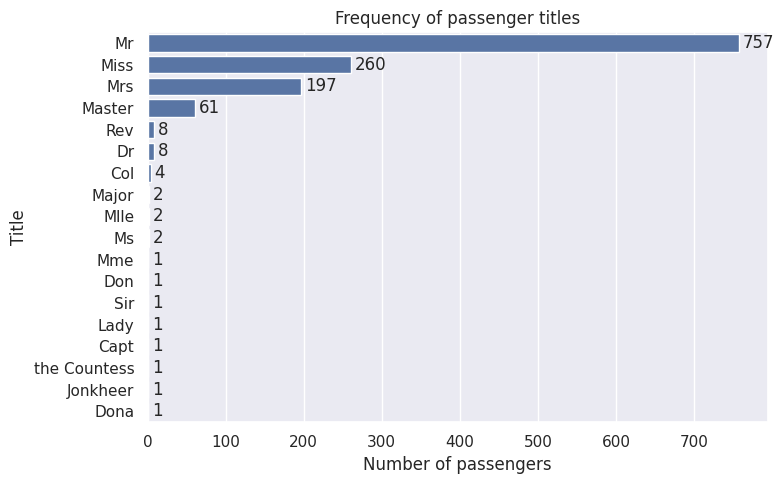

In [238]:
df_full["Title"] = df_full["Name"].str.extract(r",\s*([^\.]+)\.", expand=False)

title_counts = (
    df_full["Title"]
    .value_counts()
)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=title_counts.values,
    y=title_counts.index,
)

plt.title("Frequency of passenger titles")
plt.xlabel("Number of passengers")
plt.ylabel("Title")

for i, count in enumerate(title_counts.values):
    ax.text(
        count + 5,
        i,
        str(count),
        va="center"
    )

plt.tight_layout()
plt.show()


As with every feature created throughout this notebook, the newly engineered `Title` variable is added to the feature registry (`df_features`). Keeping the registry up to date documents the origin, type, and intended use of each feature, making the feature engineering pipeline easier to understand and reproduce.

In [239]:
df_features.loc[len(df_features)] = {
    "Name": "Title",
    "Type": "categorical",
    "Category": "extracted",
    "Source": "Name",
    "UsedInModel": False,
    "Description": "Honorific title extracted from the passenger's name."
}

### `TitleGrouped` (from `Title`)

The extracted titles include a handful of common categories together with several rare ones. Some of these rare titles exhibit extreme survival rates simply because they occur only once or twice in the dataset. For example, the title `Capt.` has a survival rate of 0%, but this "category" consists of a single passenger: Captain Edward Smith, who famously went down with the ship. While this is an interesting historical detail, it provides little statistical evidence for a machine learning model.

To reduce the impact of such sparsely represented categories, we group infrequent titles into a single `Rare` category. This preserves the distinction between common and uncommon titles while providing the model with a more robust and generalizable representation of the data.

In [240]:
# Keep the most common titles and group the remaining ones as "Rare"
common_titles = ["Mr", "Miss", "Mrs", "Master"]

df_full["TitleGrouped"] = (
    df_full["Title"]
    .where(df_full["Title"].isin(common_titles), "Rare")
)

After grouping the infrequent categories, the resulting `TitleGrouped` feature contains a small number of well-represented categories while still preserving the demographic information identified during the exploratory analysis. This representation is considerably more suitable for machine learning than the `Title` feature.

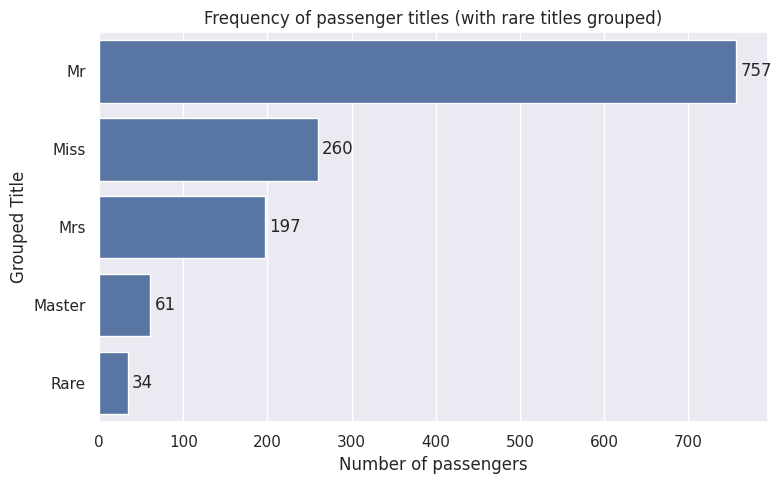

In [241]:
title_counts = (
    df_full["TitleGrouped"]
    .value_counts()
)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=title_counts.values,
    y=title_counts.index,
)

plt.title("Frequency of passenger titles (with rare titles grouped)")
plt.xlabel("Number of passengers")
plt.ylabel("Grouped Title")

for i, count in enumerate(title_counts.values):
    ax.text(
        count + 5,
        i,
        str(count),
        va="center"
    )

plt.tight_layout()
plt.show()

The figure above shows the distribution of the grouped titles. Compared to the original feature, the new representation contains only a few well-populated categories together with a single `Rare` category, making it more suitable for machine learning models while preserving the distinction between common and uncommon passenger titles.

As before, we also register the new feature in `df_features` to document its origin and intended use throughout the remainder of the project.

In [242]:
df_features.loc[len(df_features)] = {
    "Name": "TitleGrouped",
    "Type": "categorical",
    "Category": "engineered",
    "Source": "Title",
    "UsedInModel": False,
    "Description": "Passenger title with infrequent categories grouped into 'Rare'."
}

### `FamilySize` (from `SibSp` and `Parch`)

During the exploratory analysis, we observed that both `SibSp` and `Parch` exhibit a relationship with passenger survival. Rather than treating these variables independently, we combine them into a single feature representing the total number of family members traveling together.

The new feature, `FamilySize`, is defined as the number of siblings/spouses (`SibSp`) plus the number of parents/children (`Parch`), plus one to include the passenger themselves. This provides a more intuitive measure of the size of each passenger's travel group.

In [243]:
# Create the feature.
df_full["FamilySize"] = (
    df_full["SibSp"] +
    df_full["Parch"] +
    1
)

# Add new feature to df_features.
df_features.loc[len(df_features)] = {
    "Name": "FamilySize",
    "Type": "numerical",
    "Category": "engineered",
    "Source": "SibSp, Parch",
    "UsedInModel": False,
    "Description": "Total number of family members aboard, including the passenger."
}

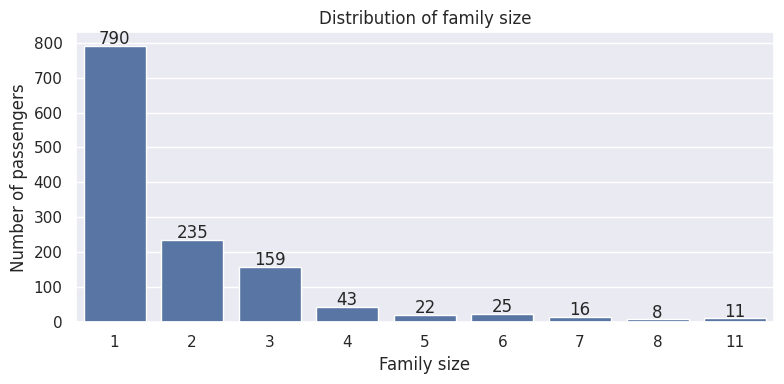

In [244]:
plt.figure(figsize=(8, 4))

ax = sns.countplot(
    data=df_full,
    x="FamilySize"
)

plt.title("Distribution of family size")
plt.xlabel("Family size")
plt.ylabel("Number of passengers")

for p in ax.patches:
    ax.text(
        p.get_x() + p.get_width() / 2,
        p.get_height() + 5,
        f"{int(p.get_height())}",
        ha="center"
    )

plt.tight_layout()
plt.show()

The distribution shows that most passengers traveled either alone or with a small number of relatives, while large family groups were comparatively rare. This engineered feature provides a more compact representation of family structure than the original `SibSp` and `Parch` variables and may help machine learning models capture patterns associated with group size.

While `FamilySize` was designed to capture the overall size of a passenger’s travel group, it is not immediately clear whether this feature has a monotonic or even consistent relationship with survival. Small families may have benefited from coordinated evacuation, whereas larger groups may have faced additional coordination difficulties. Passengers traveling alone may also exhibit distinct survival behavior compared to those traveling with family members.

To better understand this relationship, we compute the survival rate as a function of `FamilySize` and compare outcomes across different group sizes.

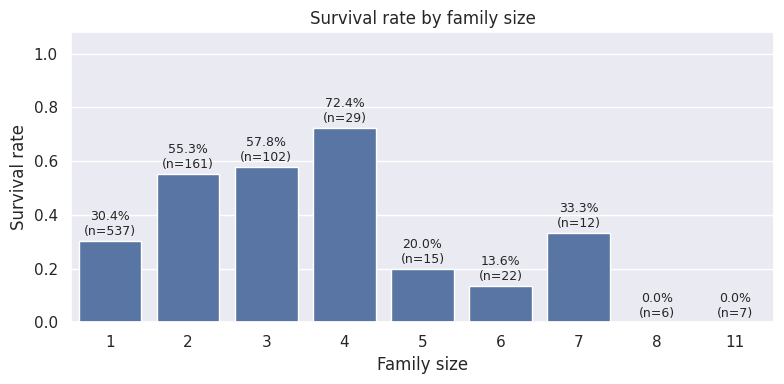

In [245]:
df_plot = df_full.loc[df_full["IsTrainSet"]].copy()

family_survival = (
    df_plot
    .groupby("FamilySize", as_index=False)
    .agg(
        SurvivalRate=("Survived", "mean"),
        Count=("Survived", "size")
    )
    .sort_values("FamilySize")
)

# IMPORTANT: force categorical order
family_survival["FamilySize"] = family_survival["FamilySize"].astype(str)
order = family_survival["FamilySize"].tolist()

plt.figure(figsize=(8, 4))

ax = sns.barplot(
    data=family_survival,
    x="FamilySize",
    y="SurvivalRate",
    order=order
)

plt.title("Survival rate by family size")
plt.xlabel("Family size")
plt.ylabel("Survival rate")

for i, row in family_survival.iterrows():
    ax.text(
        i,
        row["SurvivalRate"] + 0.01,
        f'{row["SurvivalRate"]:.1%}\n(n={row["Count"]})',
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.ylim(0, 1.08)
plt.tight_layout()
plt.show()

The results suggest that `FamilySize` is indeed associated with survival, but the relationship is non-linear. Passengers traveling in small groups tend to show higher survival rates, while those traveling alone or in very large families exhibit lower survival probabilities.

This pattern indicates that `FamilySize` captures meaningful behavioral and logistical effects during evacuation, beyond what is encoded in `SibSp` and `Parch` individually. However, the presence of variability across group sizes also suggests that this feature should be interpreted in combination with other passenger attributes rather than in isolation.

### `IsAlone` (from `FamilySize`)

The previous analysis showed that `FamilySize` is associated with survival in a non-linear way. In particular, passengers traveling alone and those in very large families tend to exhibit lower survival rates compared to passengers in small family groups.

This suggests that the *presence or absence of companions*, rather than the exact group size, may be a more informative signal for prediction. To capture this effect more directly, we derive a binary feature indicating whether a passenger was traveling alone.

In [246]:
# Create feature
df_full["IsAlone"] = (df_full["FamilySize"] == 1).astype(int)

# Add new feature to df_features
df_features.loc[len(df_features)] = {
    "Name": "IsAlone",
    "Type": "indicator",
    "Category": "engineered",
    "Source": "FamilySize",
    "UsedInModel": False,
    "Description": "Binary indicator of whether the passenger was traveling alone (1) or not (0)."
}

The `FamilySize` feature suggested that passengers traveling alone exhibit distinct survival behavior compared to those traveling with family members. However, this effect may be driven primarily by the binary distinction between traveling alone versus not alone, rather than the exact number of relatives aboard.

To investigate this hypothesis more directly, we define a binary indicator feature, `IsAlone`, and analyze how survival rates differ between these two groups.

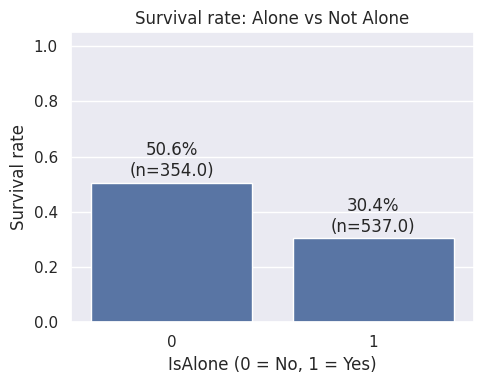

In [247]:
df_plot = df_full.loc[df_full["IsTrainSet"]].copy()

isalone_survival = (
    df_plot
    .groupby("IsAlone")["Survived"]
    .agg(SurvivalRate="mean", Count="size")
    .reset_index()
)

plt.figure(figsize=(5, 4))

ax = sns.barplot(
    data=isalone_survival,
    x="IsAlone",
    y="SurvivalRate"
)

plt.title("Survival rate: Alone vs Not Alone")
plt.xlabel("IsAlone (0 = No, 1 = Yes)")
plt.ylabel("Survival rate")

for _, row in isalone_survival.iterrows():
    ax.text(
        row["IsAlone"],
        row["SurvivalRate"] + 0.01,
        f'{row["SurvivalRate"]:.1%}\n(n={row["Count"]})',
        ha="center",
        va="bottom"
    )

plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

The plot highlights a clear difference in survival rates between passengers traveling alone and those traveling with family members. Passengers who were alone exhibit lower survival probability compared to those accompanied by at least one relative.

This result reinforces the idea that social grouping played an important role during evacuation. The binary representation `IsAlone` captures this effect in a more direct and interpretable way than the raw `FamilySize` variable, making it a strong candidate feature for downstream modeling.

### `TicketGroupSize` (from `Ticket`)

Although the `Ticket` feature appears to be a simple identifier, inspection of the dataset suggests that multiple passengers may share the same ticket number. This typically indicates that they were part of a larger booking group or traveling arrangement, which is not necessarily captured by family relationships alone (`SibSp` and `Parch`).

We therefore hypothesize that the number of passengers sharing the same ticket may provide additional information about social and economic grouping, which could be relevant for survival outcomes.

In [248]:
# Create feature
df_full["TicketGroupSize"] = df_full.groupby("Ticket")["Ticket"].transform("count")

# Register feature in df_features
df_features.loc[len(df_features)] = {
    "Name": "TicketGroupSize",
    "Type": "numerical",
    "Category": "engineered",
    "Source": "Ticket",
    "UsedInModel": False,
    "Description": "Number of passengers sharing the same ticket, capturing potential booking or travel groups."
}

The `TicketGroupSize` feature captures the size of passenger groups sharing the same ticket, which may reflect broader booking or travel arrangements beyond immediate family relationships. However, it is not immediately clear whether larger ticket groups are associated with higher or lower survival probabilities.

To investigate this relationship, we analyze survival rates across different ticket group sizes, allowing us to assess whether this feature contains meaningful predictive signal.

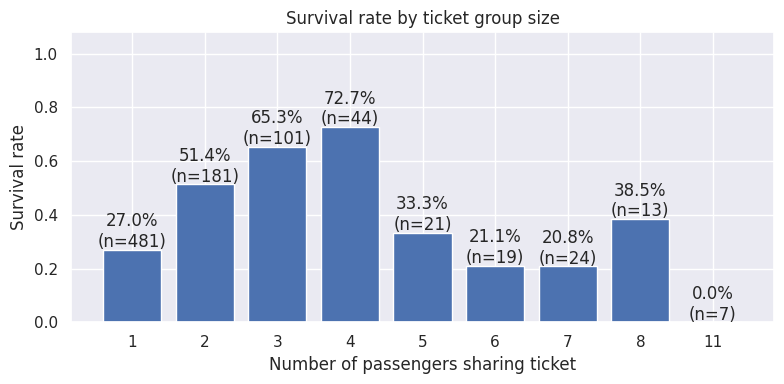

In [249]:
df_plot = df_full.loc[df_full["IsTrainSet"]].copy()

ticket_survival = (
    df_plot
    .groupby("TicketGroupSize")["Survived"]
    .agg(SurvivalRate="mean", Count="size")
    .reset_index()
    .sort_values("TicketGroupSize")
)

x = ticket_survival["TicketGroupSize"].astype(str)
y = ticket_survival["SurvivalRate"]

plt.figure(figsize=(8, 4))
plt.bar(x, y)

plt.title("Survival rate by ticket group size")
plt.xlabel("Number of passengers sharing ticket")
plt.ylabel("Survival rate")

for i, (xi, yi, n) in enumerate(zip(x, y, ticket_survival["Count"])):
    plt.text(
        i,
        yi + 0.01,
        f"{yi:.1%}\n(n={n})",
        ha="center"
    )

plt.ylim(0, 1.08)
plt.tight_layout()
plt.show()

The results indicate that survival rates vary across different ticket group sizes, although the relationship is less smooth than observed for `FamilySize`. Smaller ticket groups tend to show relatively higher survival probabilities, while larger groups are less frequent and exhibit more variability due to limited sample sizes.

Compared to `FamilySize`, this feature captures a different aspect of passenger grouping, likely reflecting booking or reservation structures rather than family relationships. As a result, `TicketGroupSize` provides complementary information that may help machine learning models identify additional patterns not captured by familial connections alone.

# `AgeCategory` (from `Age`)

The relationship between age and survival is unlikely to be linear. Historical accounts suggest that children were given priority during evacuation, while survival patterns among adults and older passengers may differ in more complex ways.

To capture these potential non-linear effects more effectively, we transform `Age` into a categorical variable by grouping passengers into meaningful age ranges. This allows the model to learn age-related patterns without assuming a strictly linear relationship.

In [250]:
# Create feature
bins = [-1, 12, 18, 35, 60, np.inf]
labels = ["Child", "Teen", "YoungAdult", "Adult", "Senior"]
df_full["AgeCategory"] = pd.cut(
    df_full["Age"],
    bins=bins,
    labels=labels
)

# Register feature in df_features
df_features.loc[len(df_features)] = {
    "Name": "AgeCategory",
    "Type": "categorical",
    "Category": "engineered",
    "Source": "Age",
    "UsedInModel": False,
    "Description": "Binned representation of passenger age capturing non-linear survival patterns across age groups."
}

The `AgeCategory` feature was introduced to capture potential non-linear effects of age on survival. While the transformation groups passengers into meaningful demographic segments, it is still necessary to verify whether these groups exhibit distinct survival patterns.

To assess this, we compare survival rates across the different age categories.

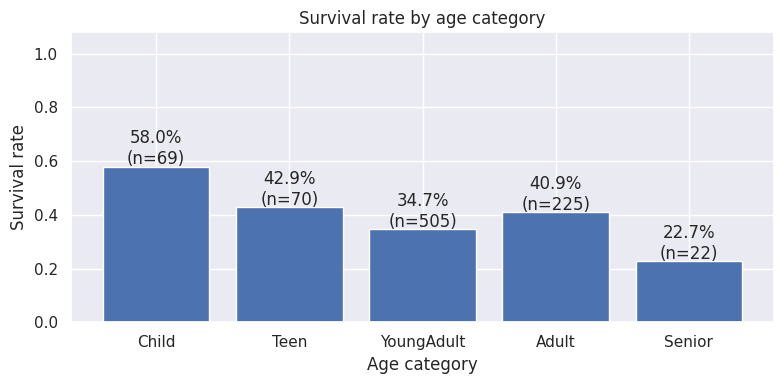

In [251]:
df_plot = df_full.loc[df_full["IsTrainSet"]].copy()

age_survival = (
    df_plot
    .groupby("AgeCategory", observed=False)["Survived"]
    .agg(SurvivalRate="mean", Count="size")
    .reindex(["Child", "Teen", "YoungAdult", "Adult", "Senior"])
    .reset_index()
)

x = age_survival["AgeCategory"].astype(str)
y = age_survival["SurvivalRate"]

plt.figure(figsize=(8, 4))
plt.bar(x, y)

plt.title("Survival rate by age category")
plt.xlabel("Age category")
plt.ylabel("Survival rate")

for i, (xi, yi, n) in enumerate(zip(x, y, age_survival["Count"])):
    plt.text(
        i,
        yi + 0.01,
        f"{yi:.1%}\n(n={n})",
        ha="center"
    )

plt.ylim(0, 1.08)
plt.tight_layout()
plt.show()

The results show clear differences in survival rates across age categories. Children exhibit the highest survival probability, consistent with evacuation priorities, while adults and older passengers show comparatively lower survival rates.

These patterns confirm that age has a non-linear relationship with survival and justify the transformation of `Age` into a categorical representation. `AgeCategory` therefore provides a more structured and model-friendly encoding of age-related effects than the raw continuous variable.

## Transformed Features

In contrast to engineered features, which introduce new representations of the data, transformed features modify the distribution or scale of existing variables without changing their underlying meaning.

These transformations are particularly useful for reducing skewness, stabilizing variance, and improving the suitability of features for machine learning algorithms that are sensitive to scale and distributional assumptions.

### `SqrtAge` (from `Age`)

Although `Age` is less skewed than `Fare`, its distribution still exhibits mild right skewness due to the presence of relatively fewer older passengers.

A square root transformation provides a gentle correction to this skewness while preserving interpretability and maintaining the continuous nature of the variable.

In [252]:
# Create feature
df_full["SqrtAge"] = np.sqrt(df_full["Age"])

# Register feature in df_features
df_features.loc[len(df_features)] = {
    "Name": "SqrtAge",
    "Type": "numerical",
    "Category": "transformed",
    "Source": "Age",
    "UsedInModel": False,
    "Description": "Square-root transformed version of Age to mildly reduce skewness while preserving interpretability."
}

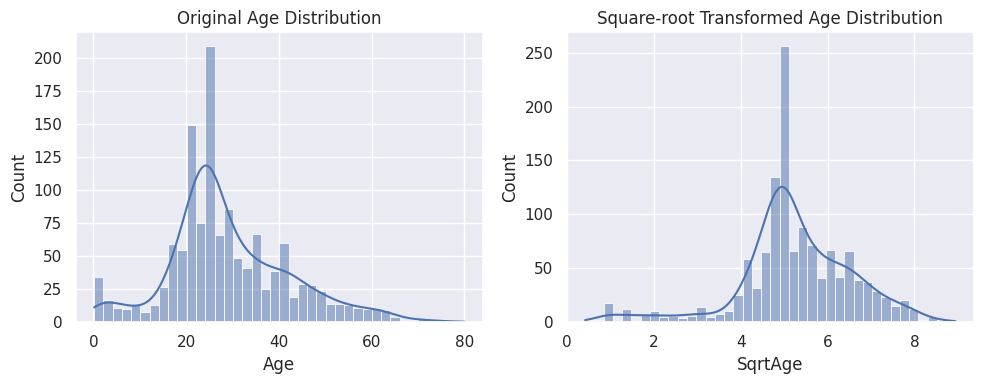

In [253]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.histplot(df_full["Age"], bins=40, kde=True)
plt.title("Original Age Distribution")

plt.subplot(1, 2, 2)
sns.histplot(df_full["SqrtAge"], bins=40, kde=True)
plt.title("Square-root Transformed Age Distribution")

plt.tight_layout()
plt.show()

The square root transformation slightly compresses higher values of `Age`, reducing mild skewness while maintaining the overall structure of the distribution.

Unlike more aggressive transformations such as the logarithm, this approach preserves interpretability and ensures that the feature remains on a continuous scale suitable for most machine learning models.

### `LogFare` (from `Fare`)

The `Fare` feature exhibits a highly skewed distribution, with a small number of passengers paying significantly higher ticket prices. Such extreme values can disproportionately influence certain machine learning models.

To mitigate this effect, we apply a logarithmic transformation to compress the range of values and reduce skewness while preserving the relative ordering of observations.

In [254]:
# Create feature
df_full["LogFare"] = np.log1p(df_full["Fare"])

# Register feature in df_features
df_features.loc[len(df_features)] = {
    "Name": "LogFare",
    "Type": "numerical",
    "Category": "transformed",
    "Source": "Fare",
    "UsedInModel": False,
    "Description": "Log-transformed version of Fare to reduce right skewness and compress extreme values."
}

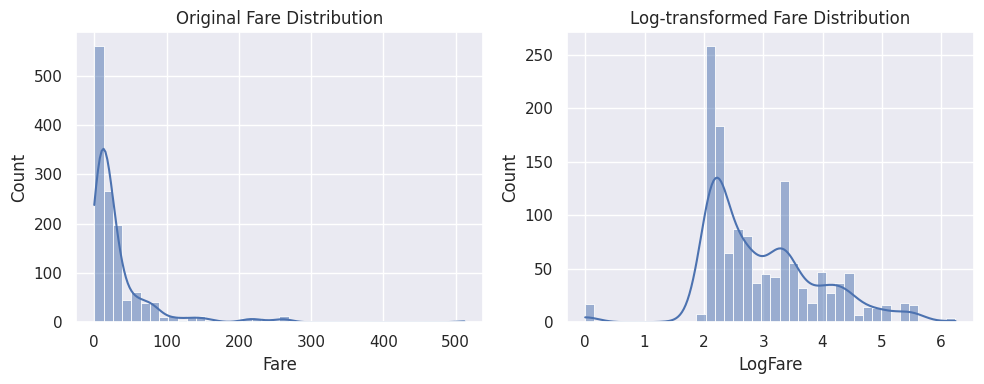

In [255]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.histplot(df_full["Fare"], bins=40, kde=True)
plt.title("Original Fare Distribution")

plt.subplot(1, 2, 2)
sns.histplot(df_full["LogFare"], bins=40, kde=True)
plt.title("Log-transformed Fare Distribution")

plt.tight_layout()
plt.show()

The logarithmic transformation significantly reduces the right skewness of the `Fare` distribution, compressing extreme values while preserving relative differences among lower and mid-range fares.

This results in a more balanced representation of the feature, which is generally more suitable for machine learning models sensitive to scale and outliers.

## Encoded Features

After feature engineering and transformation, several variables remain in categorical form. Most machine learning algorithms require numerical input, so these features must be converted into suitable representations while preserving their informational content.

In this section, we encode selected categorical variables into numerical form. The objective is to make these features directly usable by machine learning models without introducing artificial ordinal relationships or losing structural meaning.

The encoding step is restricted to features that represent categorical structure. Continuous and count-based variables that already carry meaningful magnitude information, such as `TicketGroupSize`, are retained in their original form to preserve their interpretability and signal.

### `Sex`

The `Sex` feature showed one of the strongest relationships with survival during exploratory analysis, with female passengers exhibiting significantly higher survival rates than male passengers.

To make this information usable by machine learning models, we convert the categorical variable into a binary numerical representation while preserving its full informational content.

In [256]:
# Encode Sex as binary feature
df_full["Sex"] = df_full["Sex"].map({"male": 0, "female": 1})

# Register encoded feature in df_features
df_features.loc[len(df_features)] = {
    "Name": "Sex",
    "Type": "indicator",
    "Category": "encoded",
    "Source": "Sex",
    "UsedInModel": True,
    "Description": "Binary encoding of passenger sex (0 = male, 1 = female)."
}

### `Embarked`

The `Embarked` feature indicates the port where each passenger boarded the Titanic. While this variable does not directly determine survival, exploratory analysis suggested differences in survival rates across embarkation points, likely reflecting underlying passenger composition.

To incorporate this information into machine learning models, we apply one-hot encoding, ensuring that no artificial ordering is imposed on the categories.

In [257]:
# One-hot encode Embarked
embarked_dummies = pd.get_dummies(df_full["Embarked"], prefix="Embarked")

df_full = pd.concat([df_full, embarked_dummies], axis=1)

# Register encoded features
for col in embarked_dummies.columns:
    df_features.loc[len(df_features)] = {
        "Name": col,
        "Type": "indicator",
        "Category": "encoded",
        "Source": "Embarked",
        "UsedInModel": True,
        "Description": "One-hot encoding of embarkation port."
    }

### `TitleGrouped`

The `TitleGrouped` feature captures passenger social status and demographic roles in a compact categorical form derived from `Name`. During exploratory analysis, this variable showed strong separation in survival rates, particularly between common titles such as `Mr`, `Mrs`, `Miss`, `Master`, and a grouped `Rare` category.

To incorporate this structured social signal into machine learning models, we apply one-hot encoding, ensuring that each title category is represented without imposing any ordinal relationship.

In [258]:
# One-hot encode TitleGrouped
title_dummies = pd.get_dummies(df_full["TitleGrouped"], prefix="Title")

df_full = pd.concat([df_full, title_dummies], axis=1)

# Register encoded features
for col in title_dummies.columns:
    df_features.loc[len(df_features)] = {
        "Name": col,
        "Type": "indicator",
        "Category": "encoded",
        "Source": "TitleGrouped",
        "UsedInModel": True,
        "Description": "One-hot encoding of grouped passenger titles capturing social and demographic status."
    }

### `AgeCategory`

The `AgeCategory` feature captures meaningful age segments with distinct survival patterns. However, as a categorical variable, it cannot be directly used by most machine learning models.

To incorporate this information into the modeling pipeline without imposing artificial ordinal relationships, we apply one-hot encoding to represent each age group as a separate binary feature.

In [259]:
# One-hot encode AgeCategory
age_dummies = pd.get_dummies(df_full["AgeCategory"], prefix="Age")

df_full = pd.concat([df_full, age_dummies], axis=1)

# Register encoded features
for col in age_dummies.columns:
    df_features.loc[len(df_features)] = {
        "Name": col,
        "Type": "indicator",
        "Category": "encoded",
        "Source": "AgeCategory",
        "UsedInModel": True,
        "Description": "One-hot encoded age category derived from Age."
    }

### `Pclass`

The `Pclass` feature represents passenger socioeconomic status, with clear ordinal structure (1st class > 2nd class > 3rd class). During exploratory analysis, it showed a strong association with survival, with first-class passengers exhibiting significantly higher survival rates.

To incorporate this feature into machine learning models, we preserve its ordinal nature through a direct numerical encoding, allowing models to exploit its inherent ordering.


Unlike the other features encoded in this section, `Pclass` is already represented numerically in the original dataset. However, its values are not arbitrary integers. They encode an inherent ordering corresponding to passenger socioeconomic status, with first class representing the highest status and third class the lowest.

For this reason, no additional encoding is required. We simply retain `Pclass` in its original numerical form, allowing machine learning models to exploit its ordinal structure directly.

In [260]:
# Ensure correct type
df_full["Pclass"] = df_full["Pclass"].astype(int)

# Register encoded feature in df_features
df_features.loc[
    df_features["Name"] == "Pclass",
    ["Type", "Category", "UsedInModel"]
] = ["numerical", "original", True]

Although `Pclass` appears in the encoding section, it differs from the preceding features in that no transformation is applied. Rather than converting a categorical variable into a numerical representation, we simply preserve an existing numerical feature whose ordinal structure is already meaningful for machine learning models.

## Final Feature Set

At this stage, all feature engineering, transformations, and encoding steps have been completed. The dataset now contains both the original variables and the newly created features, some of which represent alternative views of the same underlying information.

To avoid redundancy during model training, we use the feature registry (`df_features`) to identify the subset of variables that will be included in the machine learning models. The `UsedInModel` column records this decision, providing a transparent and reproducible specification of the final feature set.

In [261]:
# Original features
df_features.loc[
    df_features["Name"].isin([
        "Pclass",
        "Sex",
        "Age",
        "Fare",
        "SibSp",
        "Parch",
    ]),
    "UsedInModel"
] = True

# Engineered features
df_features.loc[
    df_features["Name"].isin([
        "FamilySize",
        "IsAlone",
        "TicketGroupSize",
    ]),
    "UsedInModel"
] = True

# Transformed features
df_features.loc[
    df_features["Name"].isin([
        "LogFare",
        "SqrtAge",
    ]),
    "UsedInModel"
] = True

# Encoded features
df_features.loc[
    df_features["Name"].isin([
        "Embarked_C",
        "Embarked_Q",
        "Embarked_S",
        "Title_Master",
        "Title_Miss",
        "Title_Mr",
        "Title_Mrs",
        "Title_Rare",
        "Age_Child",
        "Age_Teen",
        "Age_YoungAdult",
        "Age_Adult",
        "Age_Senior",
    ]),
    "UsedInModel"
] = True

In [262]:
# Features not used in the modeling stage
df_features.loc[~df_features["UsedInModel"]]

,Name,Type,Category,Source,Description,UsedInModel
1,Name,categorical,original,Name,Passenger's full name.,False
6,Ticket,categorical,original,Ticket,Ticket number.,False
8,Embarked,categorical,original,Embarked,"Port of embarkation (`C` = Cherbourg, `Q` = Qu...",False
9,Title,categorical,extracted,Name,Honorific title extracted from the passenger's...,False
10,TitleGrouped,categorical,engineered,Title,Passenger title with infrequent categories gro...,False
14,AgeCategory,categorical,engineered,Age,Binned representation of passenger age capturi...,False


In [263]:
# Features that will be used in the modeling stage
df_features.loc[df_features["UsedInModel"]]

,Name,Type,Category,Source,Description,UsedInModel
0,Pclass,numerical,original,Pclass,"Passenger ticket class (`1` = First, `2` = Sec...",True
2,Sex,categorical,original,Sex,Passenger's sex (`male` or `female`).,True
3,Age,numerical,original,Age,Passenger's age in years. Fractional values re...,True
4,SibSp,numerical,original,SibSp,Number of siblings and spouses aboard the Tita...,True
5,Parch,numerical,original,Parch,Number of parents and children aboard the Tita...,True
7,Fare,numerical,original,Fare,Passenger fare.,True
11,FamilySize,numerical,engineered,"SibSp, Parch","Total number of family members aboard, includi...",True
12,IsAlone,indicator,engineered,FamilySize,Binary indicator of whether the passenger was ...,True
13,TicketGroupSize,numerical,engineered,Ticket,"Number of passengers sharing the same ticket, ...",True
15,SqrtAge,numerical,transformed,Age,Square-root transformed version of Age to mild...,True


## Save the processed dataset

At this stage, feature engineering, transformations, and encoding have been completed. The resulting dataset contains the original variables together with the engineered and transformed features that will be used throughout the modeling stage. The feature registry (`df_features`) also records the origin, type, and modeling status of every feature, providing a transparent specification of the final feature set.

To avoid repeating these preprocessing steps in subsequent notebooks, we save both the processed dataset and the updated feature registry to disk.

In [264]:
# Save dataframes in parquet format to preserve data types
df_full.to_parquet(
    "processed_data/02_data.parquet",
    index=False
)

df_features.to_parquet(
    "processed_data/02_features.parquet",
    index=False
)

## Next Steps

The dataset is now fully prepared for machine learning. In the [next notebook](03_modeling.ipynb), we will construct the modeling dataset, split the data into training and validation sets, train several classification algorithms, and compare their predictive performance. We will also evaluate feature importance and model behavior to better understand the factors that contribute to passenger survival.